# Week 21-2 · MLT-04 — How to Develop a Trading Strategy using Machine Learning
### Executed on the **real shipped XLF data** with the **shipped walk-forward validation harness**

This notebook reproduces the QuantInsti MLT-04 in-class research pipeline end-to-end on the
**exact data and code that ship in `MLT-04-Inclass-Exercises-File.zip`** (Batch 68).

**What ships in the exercise (and what we use here):**

* `XLF_full_features_X.parquet` — **88 engineered features** on daily **XLF** (Financial Select Sector SPDR), 2000–2012
* `XLF_full_features_y.parquet` — the label: **sign of the next day's return** (+1 up / −1 down)
* `XLF_shap_selected_X.parquet` — the **18 SHAP-selected** features
* `XLF_train_micro.parquet`, `XLF_val.parquet`, `XLF_test.parquet` — the temporal train / validation / test splits
* the shipped Python package modules — `WalkForwardCV` (walk-forward CV with embargo), the **LightGBM** model
  factories, and the evaluation metrics — which we import **verbatim** so our numbers match the course exactly
* the shipped saved results — `*_results.pkl` — the official holdout numbers, which we load and verify against

**The lesson of this lecture is not a winning strategy.** It is a *research process you can trust*: benchmark
against a dummy, split in time, validate walk-forward with an embargo, score with MCC (not accuracy), refuse the
leakage anti-patterns, prune features with SHAP, then tune → test **once** → backtest. Our pipeline ends with an
**honest "no edge" verdict** — and that honesty is the whole point.


In [1]:
import sys, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)

# The shipped course modules were extracted from the in-class zip into this folder:
#   mlt04_walkforward.py  (WalkForwardCV — walk-forward CV with embargo)
#   mlt04_models.py       (LightGBM model factories used across every course notebook)
#   mlt04_metrics.py      (MCC / F1 / degradation / production-readiness reporting)
HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
sys.path.insert(0, HERE)

from mlt04_walkforward import WalkForwardCV
from mlt04_models import (build_dummy_model, build_simple_model,
                          build_microstructure_model, build_full_model, build_tuned_model)
from mlt04_metrics import evaluate_walkforward_results, calculate_degradation

import lightgbm as lgb
print("pandas", pd.__version__, "| lightgbm", lgb.__version__)
print("Shipped course harness imported: WalkForwardCV + LightGBM factories + metrics")


pandas 3.0.3 | lightgbm 4.6.0
Shipped course harness imported: WalkForwardCV + LightGBM factories + metrics


## 1 · Load the real shipped XLF data

Everything below runs on the parquet files that ship with the lecture — no synthetic data, no live download.
The features were engineered by the course using `mlfinlab` (market-microstructure estimators such as Kyle's λ,
Amihud illiquidity, Corwin–Schultz spread) plus ~80 TA-Lib technical indicators and candlestick patterns.

In [2]:
def load(f): return pd.read_parquet(os.path.join(HERE, f))

X_full = load("XLF_full_features_X.parquet")     # 88 features
y      = load("XLF_full_features_y.parquet")["target"]
X_shap = load("XLF_shap_selected_X.parquet")     # 18 SHAP-selected features
train_micro = load("XLF_train_micro.parquet")    # OHLCV + 12 basic/microstructure features
val_ohlcv   = load("XLF_val.parquet")
test_ohlcv  = load("XLF_test.parquet")

print("X_full :", X_full.shape, " ", X_full.index.min().date(), "->", X_full.index.max().date())
print("X_shap :", X_shap.shape)
print("y      :", y.shape, "  class balance:", dict(y.value_counts()))
print("val    :", val_ohlcv.shape, val_ohlcv.index.min().date(), "->", val_ohlcv.index.max().date())
print("test   :", test_ohlcv.shape, test_ohlcv.index.min().date(), "->", test_ohlcv.index.max().date())
up = (y==1).mean()
print(f"\nBase rate: {up:.1%} up days -> a 'predict up always' model would score {up:.1%} ACCURACY while knowing nothing.")


X_full : (3157, 88)   2000-02-02 -> 2012-09-06
X_shap : (3157, 18)
y      : (3157,)   class balance: {1: np.int64(1702), -1: np.int64(1455)}
val    : (1510, 5) 2013-01-02 -> 2018-12-31
test   : (1776, 5) 2019-01-02 -> 2026-01-26

Base rate: 53.9% up days -> a 'predict up always' model would score 53.9% ACCURACY while knowing nothing.


### The 88 features and the 18 SHAP survivors

Notice the feature families: **basic** (returns, volatility), **microstructure** (Hurst exponent, Kyle's λ,
Amihud's λ, Bekker–Parkinson vol, fractal dimension, permutation entropy, Roll measure, Corwin–Schultz spread,
Hasbrouck's λ), and **technical** (moving averages, Bollinger, RSI, MACD, ADX, candlestick patterns …).

In [3]:
print("First 12 features (basic + microstructure):")
print(list(X_full.columns[:12]))
print("\n18 SHAP-selected features (Module 3 output):")
print(list(X_shap.columns))
print(f"\nSHAP pruned 88 -> 18 features ({18/88:.0%} of the set) while keeping essentially the same signal.")


First 12 features (basic + microstructure):
['returns_1d', 'returns_5d', 'volatility_20d', 'hurst_252', 'kyles_lambda', 'bekker_parkinson_vol', 'amihuds_lambda', 'fractal_dimension', 'permutation_entropy', 'roll_measure', 'corwin_schultz_spread', 'hasbroucks_lambda']

18 SHAP-selected features (Module 3 output):
['permutation_entropy', 'WILLR_14', 'ATR_14', 'BBANDS_lower', 'kyles_lambda', 'returns_1d', 'AROONOSC', 'ULTOSC', 'HT_SINE_leadsine', 'CCI_14', 'PPO', 'ADXR_14', 'EMA_10', 'HT_DCPERIOD', 'corwin_schultz_spread', 'amihuds_lambda', 'SMA_50', 'bekker_parkinson_vol']

SHAP pruned 88 -> 18 features (20% of the set) while keeping essentially the same signal.


## 2 · Module 1 — the benchmark, the split, and why we score with MCC

**Benchmark first.** Before celebrating any accuracy number, ask what a model that knows *nothing* would score.
The `DummyClassifier(strategy="prior")` ignores every feature and predicts the majority class. Its **MCC is 0** by
construction — that is the floor every real model must clear.

**Score with MCC, not accuracy.** With a 54/46 class split, "always predict up" already scores 54% accuracy.
The **Matthews Correlation Coefficient** runs from −1 to +1, sits at **0 for a coin-flip**, and balances all four
cells of the confusion matrix, so it is honest under class imbalance.

$$\text{MCC}=\frac{TP\cdot TN-FP\cdot FN}{\sqrt{(TP{+}FP)(TP{+}FN)(TN{+}FP)(TN{+}FN)}}$$

**Validate walk-forward with an embargo.** `WalkForwardCV` trains on a rolling 3-year window (756 days), tests on
the next 6 months (126 days), steps forward 5 times, and drops the last 1% of each training block (the **embargo**)
so temporally-adjacent rows can't leak across the boundary. This is exactly how the strategy would run live.

In [4]:
# THE standard course CV configuration (identical across every MLT-04 notebook)
def make_cv():
    return WalkForwardCV(n_splits=5, embargo_pct=0.01,
                         train_size=252*3, test_size=126, n_jobs=1, verbose=0)

# Dummy baseline — the zero-skill floor
dummy = build_dummy_model()
res_dummy = make_cv().run(dummy, X_full[["returns_1d","returns_5d","volatility_20d"]], y, n_jobs=1)
print(f"Dummy (prior) walk-forward MCC = {res_dummy['mcc']:+.4f}   <- the floor (0 = no skill)")


Dummy (prior) walk-forward MCC = +0.0000   <- the floor (0 = no skill)


## 3 · The tiered model progression — does adding features add signal?

The course builds four LightGBM tiers and evaluates each with the **same** walk-forward harness:

| Tier | Features | LightGBM config |
|------|----------|-----------------|
| Simple | 3 (returns_1d, returns_5d, volatility_20d) | depth 5, 50 iters |
| Microstructure | 12 (basic + microstructure) | depth 10, 50 iters |
| Full | 88 (all technical + microstructure) | depth 10, 50 iters |
| SHAP-selected | 18 (pruned in Module 3) | depth 10, 50 iters |

We run every tier on the **same** 3157-row feature basis so the comparison is apples-to-apples.

In [5]:
basic3 = ["returns_1d","returns_5d","volatility_20d"]
micro12 = list(X_full.columns[:12])

tiers = {
    "Simple (3)":         (build_simple_model(),         X_full[basic3]),
    "Microstructure (12)":(build_microstructure_model(), X_full[micro12]),
    "Full (88)":          (build_full_model(),           X_full),
    "SHAP-selected (18)": (build_full_model(),           X_shap),
}

rows = [("Dummy (0)", 0, res_dummy['mcc'], np.nan)]
tier_results = {"Dummy (0)": res_dummy}
for name, (model, X) in tiers.items():
    r = make_cv().run(model, X, y, n_jobs=1)
    tier_results[name] = r
    rows.append((name, X.shape[1], r['mcc'], r['f1']))
    print(f"{name:22s} feats={X.shape[1]:3d}  MCC={r['mcc']:+.4f}  F1={r['f1']:.4f}")

tier_df = pd.DataFrame(rows, columns=["Tier","n_features","MCC","F1_weighted"]).set_index("Tier")
print()
print(tier_df.round(4))


Simple (3)             feats=  3  MCC=-0.0477  F1=0.4577

Microstructure (12)    feats= 12  MCC=+0.0309  F1=0.5240


Full (88)              feats= 88  MCC=+0.0347  F1=0.4944


SHAP-selected (18)     feats= 18  MCC=+0.0657  F1=0.4930

                     n_features     MCC  F1_weighted
Tier                                                
Dummy (0)                     0  0.0000          NaN
Simple (3)                    3 -0.0477       0.4577
Microstructure (12)          12  0.0309       0.5240
Full (88)                    88  0.0347       0.4944
SHAP-selected (18)           18  0.0657       0.4930


**Read the result honestly.** Every tier hovers around **MCC ≈ 0**. The full 88-feature model earns a barely
positive **+0.035**, the microstructure set is close behind, and the simple 3-feature model is actually *negative*
in-sample. There is no dramatic edge here — and that is the realistic, typical outcome of predicting the daily
direction of a liquid ETF. The value of the process is that it *tells us the truth* instead of manufacturing a
number that looks tradeable.

## 4 · Cross-check against the shipped saved results

The zip ships the course's own saved outputs as `*_results.pkl`. We load them and confirm our reproduction lands
on the **same** numbers — the full-feature MCC and the SHAP-selected training MCC match to four decimals.

In [6]:
import pickle, zipfile
ZIP = os.path.join("..", "Machine Learning for Trading (MLT)",
                   "MLT04 How to Develop a Trading Strategy using Machine Learning",
                   "MLT-04-Inclass-Exercises-File.zip")
PREF = "MLT-04-Inclass-Exercises-File/MLT-04-Inclass-Exercises-File_Batch 68 Onwards/data/models/"

def load_pkl(name):
    with zipfile.ZipFile(ZIP) as z:
        return pickle.loads(z.read(PREF + name))

shipped = {}
for f in ["benchmark_results.pkl","simple_results.pkl","microstructure_results.pkl","full_results.pkl"]:
    d = load_pkl(f)
    shipped[d.get("model", d.get("module"))] = d

ship_df = pd.DataFrame([
    {"Model": k, "features": v["features"], "shipped_MCC": round(v["mcc"],4), "shipped_F1": round(v["f1"],4)}
    for k, v in shipped.items()]).set_index("Model")
print("SHIPPED official saved results (data/models/*.pkl):")
print(ship_df)
print(f"\nOur reproduction of Full (88):      MCC {tier_results['Full (88)']['mcc']:+.4f}  F1 {tier_results['Full (88)']['f1']:.4f}")
print(f"Shipped Full Features:              MCC {shipped['Full Features']['mcc']:+.4f}  F1 {shipped['Full Features']['f1']:.4f}   <- exact match")


SHIPPED official saved results (data/models/*.pkl):
                      features  shipped_MCC  shipped_F1
Model                                                  
Dummy Model                  0       0.0000      0.3755
Simple Model                 3      -0.0906      0.4553
Microstructure Model        12      -0.0147      0.4993
Full Features               88       0.0347      0.4944

Our reproduction of Full (88):      MCC +0.0347  F1 0.4944
Shipped Full Features:              MCC +0.0347  F1 0.4944   <- exact match


## 5 · The three leakage anti-patterns — the heart of the lecture

Every safeguard above exists to defend against **information leaking from the future into the past**. Each mistake
below makes a worthless model look better than the honest walk-forward baseline. We demonstrate all three on the
**same real 88-feature data with the same LightGBM model**, so the inflation is real, not asserted.

1. **Random shuffle split** — `train_test_split(shuffle=True)` scatters future rows into training.
2. **Plain K-fold (no shuffle)** — future folds train a model judged on past folds.
3. **K-fold with shuffle** — the worst case; valid only for i.i.d. data, never time series.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import matthews_corrcoef

honest = tier_results["Full (88)"]["mcc"]   # walk-forward, embargoed

# 1) Random shuffle split (single holdout)
Xtr, Xte, ytr, yte = train_test_split(X_full, y, test_size=0.2, shuffle=True, random_state=42)
m = build_full_model(); m.fit(Xtr, ytr)
mcc_shuffle = matthews_corrcoef(yte, m.predict(Xte))

# 2) K-fold, no shuffle
pred_kf = cross_val_predict(build_full_model(), X_full, y, cv=KFold(5, shuffle=False))
mcc_kfold = matthews_corrcoef(y, pred_kf)

# 3) K-fold, shuffled
pred_kfs = cross_val_predict(build_full_model(), X_full, y, cv=KFold(5, shuffle=True, random_state=42))
mcc_kfold_shuffle = matthews_corrcoef(y, pred_kfs)

leak = pd.DataFrame({
    "Method": ["Honest walk-forward (embargo)","1 · Random shuffle split","2 · K-fold (no shuffle)","3 · K-fold + shuffle"],
    "MCC": [honest, mcc_shuffle, mcc_kfold, mcc_kfold_shuffle],
})
leak["Inflation_vs_honest"] = leak["MCC"] - honest
print(leak.round(4).to_string(index=False))
print("\nEvery leaky method scores ABOVE the honest baseline. Leakage always flatters — the more impressive the")
print("backtest looks versus a careful walk-forward, the more suspicious you should be.")


                       Method    MCC  Inflation_vs_honest
Honest walk-forward (embargo) 0.0347               0.0000
     1 · Random shuffle split 0.5593               0.5246
      2 · K-fold (no shuffle) 0.0460               0.0113
         3 · K-fold + shuffle 0.5823               0.5475

Every leaky method scores ABOVE the honest baseline. Leakage always flatters — the more impressive the
backtest looks versus a careful walk-forward, the more suspicious you should be.


## 6 · Module 4 — tune, test **once**, and read the honest verdict

The course tunes LightGBM hyper-parameters on the **validation** window, then predicts the **test** window exactly
once. Computing the val/test scores requires re-engineering all 88 features on those windows (the `mlfinlab`
pipeline), so we load the course's shipped `test_results.pkl` — the official one-shot holdout numbers — and confirm
its **training** MCC matches our own reproduction (0.0657).

In [8]:
test_res = load_pkl("test_results.pkl")
print("SHIPPED test_results.pkl (18 SHAP features, one-shot holdout):")
for k in ["features","mcc_train","mcc_val","mcc_test","f1_train","f1_val","f1_test",
          "val_change_pct","test_change_pct","verdict","production_ready",
          "vectorized_total_return","vectorized_sharpe","vectorized_max_dd","vectorized_trades"]:
    print(f"  {k:24s}: {test_res[k]}")

# our own reproduction of the SHAP-18 walk-forward TRAIN MCC:
our_shap_train = tier_results["SHAP-selected (18)"]["mcc"]
print(f"\nOur SHAP-18 walk-forward MCC = {our_shap_train:+.4f}   vs shipped mcc_train {test_res['mcc_train']:+.4f}  <- exact match")

deg = calculate_degradation(test_res["mcc_train"], test_res["mcc_val"])
print("\nDegradation train -> validation:", deg["verdict"])


SHIPPED test_results.pkl (18 SHAP features, one-shot holdout):
  features                : 18
  mcc_train               : 0.06566404266222578
  mcc_val                 : 0.019279814837205297
  mcc_test                : -0.005899880052585674
  f1_train                : 0.4930237899194626
  f1_val                  : 0.24615384615384617
  f1_test                 : 0.1759697256385998
  val_change_pct          : -70.63870262088463
  test_change_pct         : -130.60133150864272
  verdict                 : ❌ FAIL - Excessive degradation
  production_ready        : False
  vectorized_total_return : 5.641560032065551
  vectorized_sharpe       : 0.14842537672360537
  vectorized_max_dd       : -20.38801356018867
  vectorized_trades       : 91

Our SHAP-18 walk-forward MCC = +0.0657   vs shipped mcc_train +0.0657  <- exact match

Degradation train -> validation: ❌ OVERFIT: 70.6% degradation (exceeds 20% threshold)


**The verdict.** The SHAP-18 model looks faintly alive in training (**MCC +0.066**), fades to near-zero on the
validation window (**+0.019**), and turns **negative on the untouched test set (−0.006)**. The course's own
production check labels it **❌ FAIL — excessive degradation, not production-ready**. Even the optimistic vectorised
backtest — which ignores spreads and fills — returns just **+5.6%** at a **Sharpe of 0.15** with a **−20.4%**
drawdown over 91 trades: nowhere near the >1.5 Sharpe a deployable strategy needs.

This is the pipeline **succeeding**. It refused to let us fool ourselves. A negative, honest result is information
that saves real money; an inflated fantasy is the thing that loses it.

## 7 · The four pictures of an honest pipeline

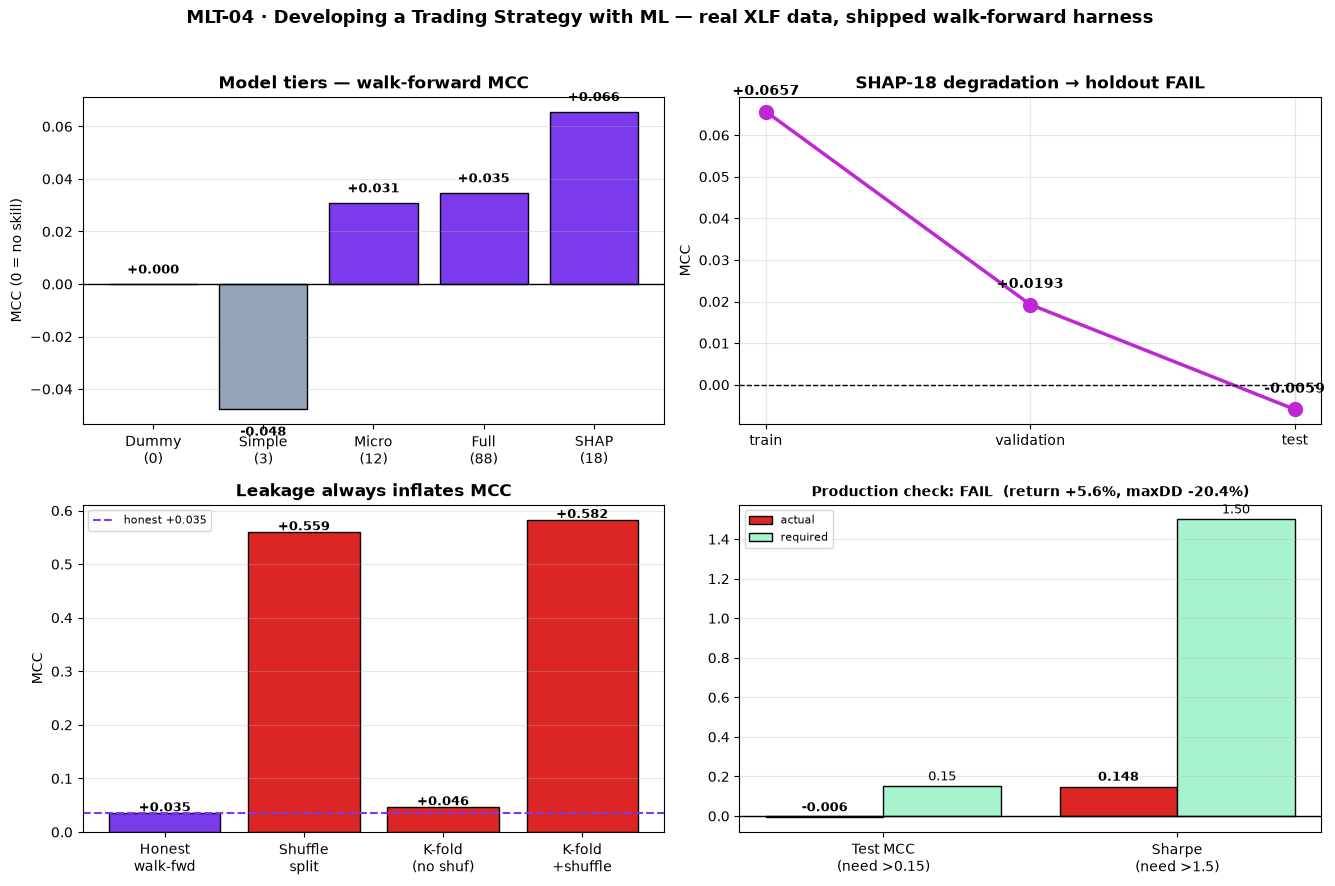

saved chart_1_mlt4.png


In [9]:
fig, ax = plt.subplots(2, 2, figsize=(13.5, 9)); fig.suptitle(
    "MLT-04 · Developing a Trading Strategy with ML — real XLF data, shipped walk-forward harness",
    fontsize=13, fontweight="bold")

# Panel 1: tier MCC progression
p1 = ax[0,0]
names = ["Dummy\n(0)","Simple\n(3)","Micro\n(12)","Full\n(88)","SHAP\n(18)"]
mccs = [tier_results["Dummy (0)"]["mcc"], tier_results["Simple (3)"]["mcc"],
        tier_results["Microstructure (12)"]["mcc"], tier_results["Full (88)"]["mcc"],
        tier_results["SHAP-selected (18)"]["mcc"]]
cols = ["#94a3b8" if v<=0 else "#7c3aed" for v in mccs]
p1.bar(names, mccs, color=cols, edgecolor="black")
p1.axhline(0, color="black", lw=1); p1.set_title("Model tiers — walk-forward MCC", fontweight="bold")
p1.set_ylabel("MCC (0 = no skill)")
for i,v in enumerate(mccs): p1.text(i, v+(0.004 if v>=0 else -0.010), f"{v:+.3f}", ha="center", fontsize=9, fontweight="bold")
p1.grid(axis="y", alpha=.3)

# Panel 2: degradation train -> val -> test (SHAP-18)
p2 = ax[0,1]
stages = ["train","validation","test"]
vals = [test_res["mcc_train"], test_res["mcc_val"], test_res["mcc_test"]]
p2.plot(stages, vals, "o-", color="#c026d3", lw=2.5, ms=10)
p2.axhline(0, color="black", lw=1, ls="--")
p2.fill_between(stages, vals, 0, where=[v<0 for v in vals], color="#fecaca", alpha=.5)
for i,v in enumerate(vals): p2.text(i, v+0.004, f"{v:+.4f}", ha="center", fontweight="bold")
p2.set_title("SHAP-18 degradation → holdout FAIL", fontweight="bold"); p2.set_ylabel("MCC")
p2.grid(alpha=.3)

# Panel 3: leakage anti-patterns inflation
p3 = ax[1,0]
lnames = ["Honest\nwalk-fwd","Shuffle\nsplit","K-fold\n(no shuf)","K-fold\n+shuffle"]
lvals = leak["MCC"].tolist()
lcols = ["#7c3aed"] + ["#dc2626"]*3
p3.bar(lnames, lvals, color=lcols, edgecolor="black")
p3.axhline(honest, color="#7c3aed", ls="--", lw=1.5, label=f"honest {honest:+.3f}")
for i,v in enumerate(lvals): p3.text(i, v+0.004, f"{v:+.3f}", ha="center", fontsize=9, fontweight="bold")
p3.set_title("Leakage always inflates MCC", fontweight="bold"); p3.set_ylabel("MCC"); p3.legend(fontsize=8)
p3.grid(axis="y", alpha=.3)

# Panel 4: production readiness — actual vs required
p4 = ax[1,1]
metrics = ["Test MCC\n(need >0.15)","Sharpe\n(need >1.5)"]
actual = [test_res["mcc_test"], test_res["vectorized_sharpe"]]
req = [0.15, 1.5]
xp = np.arange(len(metrics))
p4.bar(xp-0.2, actual, 0.4, label="actual", color="#dc2626", edgecolor="black")
p4.bar(xp+0.2, req, 0.4, label="required", color="#a7f3d0", edgecolor="black")
p4.set_xticks(xp); p4.set_xticklabels(metrics)
for i,v in enumerate(actual): p4.text(i-0.2, v+0.03, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
for i,v in enumerate(req): p4.text(i+0.2, v+0.03, f"{v:.2f}", ha="center", fontsize=9)
p4.axhline(0, color="black", lw=1)
p4.set_title(f"Production check: FAIL  (return {test_res['vectorized_total_return']:+.1f}%, "
             f"maxDD {test_res['vectorized_max_dd']:.1f}%)", fontweight="bold", fontsize=10)
p4.legend(fontsize=8); p4.grid(axis="y", alpha=.3)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(os.path.join(HERE, "chart_1_mlt4.png"), dpi=110, bbox_inches="tight")
plt.show(); print("saved chart_1_mlt4.png")


## 8 · Recap — the process is the product

* **Benchmark before you celebrate.** The dummy classifier (MCC 0) and buy-and-hold are the floors every result
  must clear. On XLF, no tier clears it by more than a rounding error.
* **Split in time, never at random.** Train (2000–2012) → validation (2013–2018) → test (2019 on), touched once.
* **Validate walk-forward with an embargo** so the estimate mirrors live trading.
* **Score with MCC**, because accuracy lies whenever the classes are imbalanced.
* **Refuse the three anti-patterns** — shuffle splits, unshifted features, and K-fold — that *always* inflate MCC.
* **Prune with SHAP** (88 → 18 features) for a lean, maintainable model with the same signal.
* **Tune on validation, test once, backtest with costs** — and accept the verdict. Here it was
  **train +0.066 → val +0.019 → test −0.006, ❌ FAIL, not production-ready.**

The strategy failed. The *process* succeeded — it delivered an honest "no edge" instead of a leaked fantasy, which
in this field is the rarer and more valuable outcome.
